In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def show_img(img):
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [16]:
def gray_scale(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray

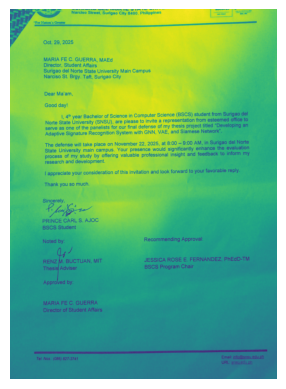

In [43]:
img = cv2.imread('docum.jfif')
gray = gray_scale(img)
show_img(gray)

In [44]:
def adaptive_thresh(gray):
    thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY_INV, 15, 8
    )
    return thresh

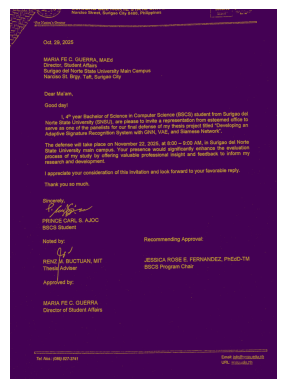

In [45]:
adap_t = adaptive_thresh(gray)
show_img(adap_t)

In [46]:
def clean(thresh):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    return clean

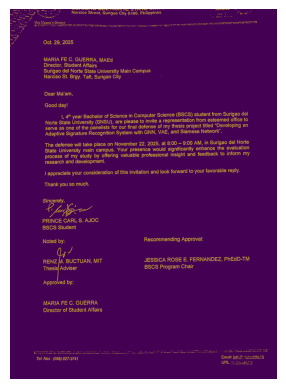

In [47]:
cln = clean(adap_t)
show_img(cln)

In [48]:
def mask_contours(clean, gray):
    contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(gray)

    return contours, mask

In [49]:
c, m = mask_contours(cln, gray)
# c = contours(cln)

In [50]:
def draw(contours, mask):
    for c in contours:
        area = cv2.contourArea(c)
        if area > 150:  # Keep only large components (likely signature strokes)
            cv2.drawContours(mask, [c], -1, 255, -1)

    return mask

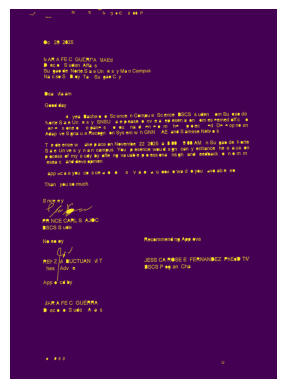

In [51]:
d = draw(c, m)
show_img(d)

In [52]:
sign = cv2.bitwise_and(img, img, mask=d)

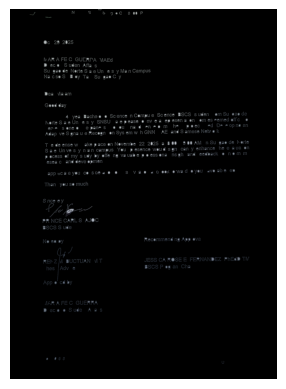

In [53]:
show_img(sign)

In [54]:
def crop(signature, mask):
    ys, xs = mask.nonzero()
    cropped_signatures = signature[min(ys):max(ys), min(xs):max(xs)]
    return cropped_signatures

In [55]:
signs = crop(sign, d)

In [56]:
len(signs)

3307

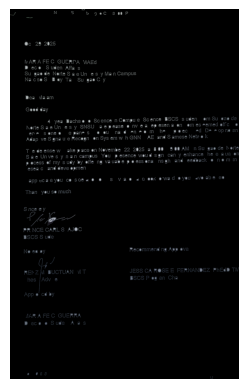

In [57]:
show_img(signs)